# Detectar de Contenido Multiclase con `unitary/unbiased-toxic-roberta` + Fine-Tune en español
**Modelo base:** [`unitary/unbiased-toxic-roberta`](https://huggingface.co/unitary/unbiased-toxic-roberta)  
**Dataset de ajuste:** [`dolfsai/toxic_es`](https://huggingface.co/datasets/dolfsai/toxic_es) + ejemplos `non_toxic` sintéticos  
**Arquitectura:** RoBERTa-base (125 M parámetros)  

## Estrategia de clasificación
Clasificación **multiclase** con N+1 clases:
- Clase `non_toxic` → textos limpios (añadida explícitamente, ya que el dataset base solo contiene ejemplos tóxicos)
- 45 subcategorías de toxicidad (xenophobia, discrimination, misogyny, etc.)

Con **un solo modelo** obtenemos:
1. Si el texto es tóxico o no
2. El tipo específico de toxicidad

## 1. Instalación de dependencias

In [1]:
!pip install transformers datasets torch scikit-learn evaluate accelerate sentencepiece gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


## 2. Importaciones y configuración

In [2]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List, Tuple
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
from datasets import load_dataset, Dataset, concatenate_datasets
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import evaluate
import warnings
warnings.filterwarnings('ignore')

# Constantes globales
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME    = 'unitary/unbiased-toxic-roberta'
OUTPUT_DIR    = './finetuned_roberta_es_multiclass'
SAVE_PATH     = './roberta_toxic_es_multiclass_temp'
MAX_LENGTH    = 128
TRAIN_SAMPLES = 20000   # incluye muestras no tóxicas
VAL_SAMPLES   = 4000
# constante para la clase no tóxica
NON_TOXIC_LABEL = 'non_toxic'

Path(OUTPUT_DIR).mkdir(exist_ok=True)
Path(SAVE_PATH).mkdir(exist_ok=True)

print(f'Dispositivo: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'NON_TOXIC_LABEL = {NON_TOXIC_LABEL!r}  ← referencia única para clase limpia')

Dispositivo: cuda
GPU: Tesla T4
VRAM total: 14.6 GB
NON_TOXIC_LABEL = 'non_toxic'  ← referencia única para clase limpia


## 3. Carga del modelo base e inferencia directa (pre fine-tune)

In [3]:
print(f'Cargando modelo base: {MODEL_NAME} ...')
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
base_model = base_model.to(DEVICE)
base_model.eval()

BASE_LABELS = list(base_model.config.id2label.values())
print(f'Categorías base: {BASE_LABELS}')
print(f'Parámetros totales: {sum(p.numel() for p in base_model.parameters()):,}')

Cargando modelo base: unitary/unbiased-toxic-roberta ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: unitary/unbiased-toxic-roberta
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Categorías base: ['toxicity', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'sexual_explicit', 'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish', 'muslim', 'black', 'white', 'psychiatric_or_mental_illness']
Parámetros totales: 124,657,936


In [4]:
def predict_base(text: str, threshold: float = 0.5) -> dict:
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=512, padding=True
    ).to(DEVICE)
    with torch.no_grad():
        outputs = base_model(**inputs)
    scores = torch.sigmoid(outputs.logits).cpu().numpy()[0]
    return {
        'scores':   {l: round(float(s), 4) for l, s in zip(BASE_LABELS, scores)},
        'is_toxic': bool(max(scores) >= threshold),
        'max_score': round(float(max(scores)), 4),
    }

test_es = [
    "El partido terminó en empate, fue un buen juego.",
    "Eres un completo idiota que no sirve para nada.",
    "Los inmigrantes son todos criminales.",
    "Me parece una solución muy creativa, enhorabuena.",
    "Te voy a partir la cara si te veo por aquí.",
]

print('=== Resultados MODELO BASE (sin fine-tune) ===\n')
for t in test_es:
    r = predict_base(t)
    flag = 'X' if r['is_toxic'] else 'O'
    print(f"{flag} [{r['max_score']:.3f}] {t[:70]}")

=== Resultados MODELO BASE (sin fine-tune) ===

O [0.004] El partido terminó en empate, fue un buen juego.
O [0.482] Eres un completo idiota que no sirve para nada.
O [0.339] Los inmigrantes son todos criminales.
O [0.001] Me parece una solución muy creativa, enhorabuena.
O [0.001] Te voy a partir la cara si te veo por aquí.


## 4. Carga y exploración de `dolfsai/toxic_es`

El dataset solo contiene filas `category == 'censorship'` (textos tóxicos).  
**No existe ninguna fila `non_toxic`** — esto se corrige en la sección 5.

In [5]:
print('Cargando dataset dolfsai/toxic_es ...')
raw_dataset = load_dataset('dolfsai/toxic_es')
print(f'Estructura: {raw_dataset}')
print(f'Columnas: {raw_dataset["train"].column_names}')

train_df = raw_dataset['train'].to_pandas().reset_index(drop=True)  # drop=True evita columna '__index_level_0__'
print(f'\nTotal ejemplos: {len(train_df):,}')
print(f'Valores únicos de "category": {train_df["category"].unique().tolist()}')
print(f'Número de subcategorías únicas: {train_df["subcategory"].nunique()}')
print(f'\nDistribución de subcategorías (top 15):')
print(train_df['subcategory'].value_counts().head(15))

Cargando dataset dolfsai/toxic_es ...


README.md: 0.00B [00:00, ?B/s]

train.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/50896 [00:00<?, ? examples/s]

Estructura: DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'subcategory'],
        num_rows: 50896
    })
})
Columnas: ['text', 'category', 'subcategory']

Total ejemplos: 50,896
Valores únicos de "category": ['censorship']
Número de subcategorías únicas: 45

Distribución de subcategorías (top 15):
subcategory
promotion                     5986
instructions                  4951
graphic_descriptions          3072
descriptions                  2982
sex                           1030
detailed_descriptions         1006
manufacturing_distribution    1006
insults_defamation            1004
excessive_swearing            1003
labor_exploitation            1001
hacking_activities            1001
guns                          1001
propaganda                    1000
pornography                   1000
security                       999
Name: count, dtype: int64


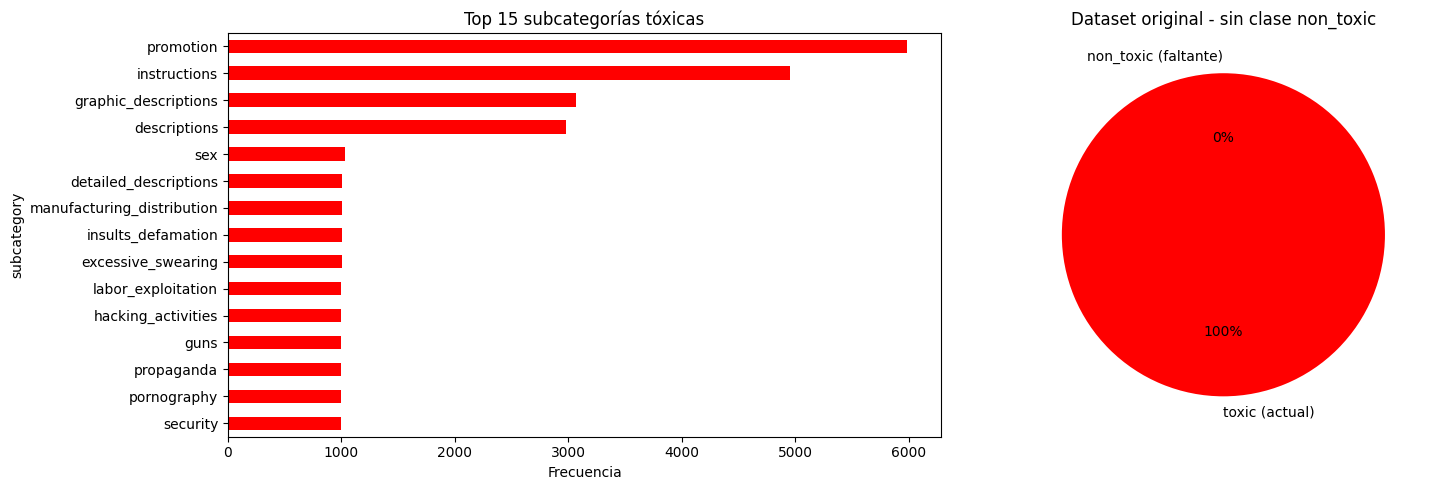

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

train_df['subcategory'].value_counts().head(15).plot(
    kind='barh', ax=axes[0], color='red'
)
axes[0].set_title('Top 15 subcategorías tóxicas')
axes[0].set_xlabel('Frecuencia')
axes[0].invert_yaxis()

# Gráfico de sectores: proporción tóxico vs no tóxico
axes[1].pie(
    [len(train_df), 0],
    labels=['toxic (actual)', 'non_toxic (faltante)'],
    colors=['red', 'green'],
    autopct='%1.0f%%',
    startangle=90,
)
axes[1].set_title('Dataset original - sin clase non_toxic')

plt.tight_layout()
plt.savefig('class_distribution_original.png', dpi=150)
plt.show()

## 5. Añadir ejemplos `non_toxic` reales

Como `dolfsai/toxic_es` no contiene texto no tóxico, cargamos reseñas en español de `mteb/amazon_reviews_multi` (dominio neutral) y las etiquetamos como `non_toxic`.
Se usa un número similar al de la subcategoría más frecuente del dataset tóxico para equilibrar clases.

In [7]:
# Cargar textos en español
NON_TOXIC_SAMPLES = 5000   # ejemplos no tóxicos a añadir al dataset

print('Cargando textos no tóxicos desde wikimedia/wikipedia (es) ...')
wiki_ds = load_dataset(
    'wikimedia/wikipedia',
    '20231101.es',
    split='train',
    streaming=True, # streaming evita descargar los ~20 GB completos
)

# Recoger suficientes artículos hasta tener NON_TOXIC_SAMPLES párrafos válidos
neutral_texts = []
for article in wiki_ds:
    # Cada artículo tiene campo 'text'; partimos en párrafos y filtramos por longitud
    paragraphs = [
        p.strip()
        for p in article['text'].split('\n')
        if 20 < len(p.strip()) < 300
        and not p.strip().startswith('==')
    ]
    neutral_texts.extend(paragraphs)
    if len(neutral_texts) >= NON_TOXIC_SAMPLES * 3:   # recolectar extra para poder filtrar
        break

# Muestra aleatoria reproducible
rng = np.random.default_rng(42)
idx = rng.choice(len(neutral_texts), size=min(NON_TOXIC_SAMPLES, len(neutral_texts)), replace=False)
neutral_texts = [neutral_texts[i] for i in idx]

amazon_df = pd.DataFrame({'text': neutral_texts}).reset_index(drop=True)
amazon_df['category']    = NON_TOXIC_LABEL
amazon_df['subcategory'] = NON_TOXIC_LABEL

print(f'Ejemplos no tóxicos cargados: {len(amazon_df):,}')
print(amazon_df.head(3))

Cargando textos no tóxicos desde wikimedia/wikipedia (es) ...


README.md: 0.00B [00:00, ?B/s]

Ejemplos no tóxicos cargados: 5,000
                                                text   category subcategory
0  Embriología: Estudia el desarrollo embrionario...  non_toxic   non_toxic
1  Cintio, proveniente de su nacimiento en el Mon...  non_toxic   non_toxic
2   Brachiaria humbertiana A.Camus (1932 publ. 1933)  non_toxic   non_toxic


In [8]:
# Construir etiqueta unificada
# usa NON_TOXIC_LABEL - no strings literales dispersos
def build_unified_label(row) -> str:
    """Si es tóxico devuelve la subcategoría; si no, NON_TOXIC_LABEL."""
    if row['category'] == 'censorship':
        return row['subcategory']
    return NON_TOXIC_LABEL

# Dataset tóxico
toxic_df = train_df[['text', 'category', 'subcategory']].copy().reset_index(drop=True)
toxic_df['unified_label'] = toxic_df.apply(build_unified_label, axis=1)

# Dataset no tóxico
amazon_df['unified_label'] = NON_TOXIC_LABEL

# Combinar
combined_df = pd.concat(
    [toxic_df[['text', 'unified_label']], amazon_df[['text', 'unified_label']]],
    ignore_index=True
).dropna().reset_index(drop=True)  # reset_index(drop=True) siempre

print(f'Dataset combinado: {len(combined_df):,} filas')
print(f'\nDistribución unified_label (top 10):')
print(combined_df['unified_label'].value_counts().head(10))

# Verificar que NON_TOXIC_LABEL existe
assert NON_TOXIC_LABEL in combined_df['unified_label'].values, \
    f'ERROR: {NON_TOXIC_LABEL!r} no encontrado en unified_label'
print(f'\n Clase {NON_TOXIC_LABEL!r} presente: {(combined_df["unified_label"]==NON_TOXIC_LABEL).sum():,} ejemplos')

Dataset combinado: 55,896 filas

Distribución unified_label (top 10):
unified_label
promotion                     5986
non_toxic                     5000
instructions                  4951
graphic_descriptions          3072
descriptions                  2982
sex                           1030
manufacturing_distribution    1006
detailed_descriptions         1006
insults_defamation            1004
excessive_swearing            1003
Name: count, dtype: int64

 Clase 'non_toxic' presente: 5,000 ejemplos


## 6. Construcción del mapeo de etiquetas

In [9]:
all_labels = sorted(combined_df['unified_label'].unique().tolist())
label2id   = {label: idx for idx, label in enumerate(all_labels)}
id2label   = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(all_labels)

print(f'Número total de clases: {NUM_LABELS}')
print(f'ID de {NON_TOXIC_LABEL!r}: {label2id[NON_TOXIC_LABEL]}')
print(f'\nMapeo id2label:')
for idx, lbl in id2label.items():
    marker = ' ← non_toxic' if lbl == NON_TOXIC_LABEL else ''
    print(f'  {idx:>3}: {lbl}{marker}')

# guardar el ID como constante para no repetir label2id[NON_TOXIC_LABEL] en todo el código
NON_TOXIC_ID = label2id[NON_TOXIC_LABEL]
print(f'\nNON_TOXIC_ID = {NON_TOXIC_ID}')

Número total de clases: 46
ID de 'non_toxic': 34

Mapeo id2label:
    0: 1
    1: abuse_exploitation
    2: against_religion
    3: apology
    4: bulling
    5: child_exploitation
    6: chileno
    7: crime_instructions
    8: descriptions
    9: detailed_descriptions
   10: drug_promotion
   11: es
   12: excessive_swearing
   13: explicit_language
   14: general_insults
   15: glorification
   16: graphic_descriptions
   17: guns
   18: hacking_activities
   19: hascosva
   20: hate_speech
   21: haternet
   22: hateval
   23: homomex
   24: homophobia_transphobia
   25: ilegal_exploitation
   26: illegal_activity
   27: instructions
   28: insults
   29: insults_defamation
   30: labor_exploitation
   31: lying_prompts
   32: manufacturing_distribution
   33: misogyny_sexism
   34: non_toxic ← non_toxic
   35: offensive_religion
   36: pornography
   37: promotion
   38: propaganda
   39: racism
   40: scams
   41: security
   42: sex
   43: substance_abuse
   44: threats_coercion

## 7. Preprocesamiento y tokenización

### Verificación de distribución estratificada

Se añade `assert` y visualización para garantizar que ninguna clase queda con menos de `MIN_SAMPLES_PER_CLASS` ejemplos.

In [10]:
MIN_SAMPLES_PER_CLASS = 5  # garantía mínima por clase en train

def preprocess_dataset(df: pd.DataFrame, max_samples: int = None, split_name: str = '') -> Dataset:
    df = df.dropna(subset=['text', 'unified_label']).copy()
    df['text']   = df['text'].astype(str).str.strip()
    df = df[df['text'].str.len() > 2].reset_index(drop=True)  # FIX #2
    df['labels'] = df['unified_label'].map(label2id).astype(int)

    if max_samples and len(df) > max_samples:
        df = df.groupby('labels', group_keys=False).apply(
            lambda x: x.sample(
                min(len(x), max(MIN_SAMPLES_PER_CLASS,
                                int(max_samples * len(x) / len(df)))),
                random_state=42
            )
        ).reset_index(drop=True)

    # verificar distribución antes de entrenar
    dist = df['labels'].value_counts()
    degenerate = dist[dist < MIN_SAMPLES_PER_CLASS]
    if not degenerate.empty:
        print(f'  [{split_name}] Clases con menos de {MIN_SAMPLES_PER_CLASS} muestras:')
        for lbl_id, cnt in degenerate.items():
            print(f'     {id2label[lbl_id]}: {cnt}')
    else:
        print(f' [{split_name}] Distribución OK — mín {dist.min()} muestras/clase, máx {dist.max()}')

    hf_dataset = Dataset.from_pandas(df[['text', 'labels']], preserve_index=False)

    def tokenize_fn(batch):
        return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding=False)

    tokenized = hf_dataset.map(tokenize_fn, batched=True, remove_columns=['text'])
    tokenized.set_format('torch')
    return tokenized


# Split train/val sobre el dataset combinado
combined_hf = Dataset.from_pandas(combined_df[['text', 'unified_label']], preserve_index=False)
split        = combined_hf.train_test_split(test_size=0.15, seed=42)
train_raw_df = split['train'].to_pandas().reset_index(drop=True)
val_raw_df   = split['test'].to_pandas().reset_index(drop=True)

print(f'Preprocesando {TRAIN_SAMPLES} ejemplos de entrenamiento...')
train_ds = preprocess_dataset(train_raw_df, max_samples=TRAIN_SAMPLES, split_name='train')
val_ds   = preprocess_dataset(val_raw_df,   max_samples=VAL_SAMPLES,   split_name='val')

print(f'\nTrain: {len(train_ds):,} ejemplos | Val: {len(val_ds):,} ejemplos')

Preprocesando 20000 ejemplos de entrenamiento...
 [train] Distribución OK — mín 10 muestras/clase, máx 2140


Map:   0%|          | 0/19977 [00:00<?, ? examples/s]

  [val] Clases con menos de 5 muestras:
     homomex: 3


Map:   0%|          | 0/3981 [00:00<?, ? examples/s]


Train: 19,977 ejemplos | Val: 3,981 ejemplos


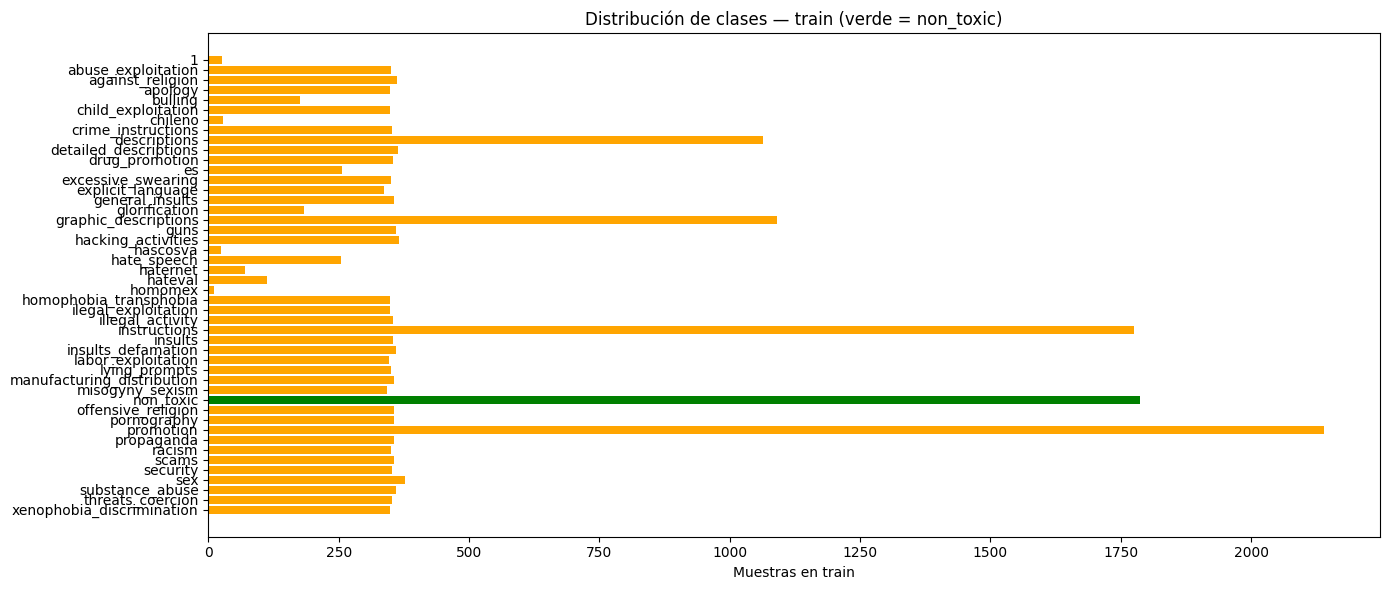

In [11]:
# Visualización de distribución final
train_counts = Counter(int(x) for x in train_ds['labels'])
labels_sorted = sorted(train_counts.keys())
counts_sorted = [train_counts[k] for k in labels_sorted]
names_sorted  = [id2label[k] for k in labels_sorted]

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['green' if n == NON_TOXIC_LABEL else 'orange' for n in names_sorted]
ax.barh(names_sorted, counts_sorted, color=colors)
ax.set_xlabel('Muestras en train')
ax.set_title('Distribución de clases — train (verde = non_toxic)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('class_distribution_fixed.png', dpi=150)
plt.show()

## 8. Inicialización del modelo multiclase

In [12]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
ft_model = ft_model.to(DEVICE)
ft_model.config.problem_type = 'single_label_classification'

print(f'Modelo listo para fine-tune multiclase ({NUM_LABELS} clases).')
print(f'Parámetros totales: {sum(p.numel() for p in ft_model.parameters()):,}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: unitary/unbiased-toxic-roberta
Key                             | Status     |                                                                                       
--------------------------------+------------+---------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                       
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([16, 768]) vs model:torch.Size([46, 768])
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([16]) vs model:torch.Size([46])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Modelo listo para fine-tune multiclase (46 clases).
Parámetros totales: 124,681,006


## 9. Métricas y entrenamiento

`warmup_steps` en lugar de `warmup_ratio` (deprecated en v5.2)

In [13]:
from transformers import EarlyStoppingCallback

accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
    return {'accuracy': acc['accuracy'], 'f1': f1['f1']}

BATCH_SIZE  = 16 if DEVICE == 'cuda' else 4
NUM_EPOCHS  = 12 if DEVICE == 'cuda' else 1

# Class weights para compensar desbalance entre subcategorías
from torch import nn
from collections import Counter

label_counts = Counter(int(x) for x in train_ds['labels'])
total        = sum(label_counts.values())
weights      = torch.tensor(
    [total / (NUM_LABELS * label_counts.get(i, 1)) for i in range(NUM_LABELS)],
    dtype=torch.float32
).to(DEVICE)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss    = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

# calcular warmup_steps explícitamente
steps_per_epoch = len(train_ds) // BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(0.03 * total_steps)
print(f'steps/epoch={steps_per_epoch}  total_steps={total_steps}  warmup_steps={warmup_steps}')

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=8e-6,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    lr_scheduler_type='cosine',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    label_smoothing_factor=0.1,
    logging_steps=50,
    fp16=(DEVICE == 'cuda'),
    dataloader_num_workers=0,
    report_to='none',
    seed=42,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.002,
        )
    ],
)

print(f'Batch size: {BATCH_SIZE} | Épocas máx: {NUM_EPOCHS} | LR: 8e-6 | Early stop: patience=3')

steps/epoch=1248  total_steps=14976  warmup_steps=449
Batch size: 16 | Épocas máx: 12 | LR: 8e-6 | Early stop: patience=3


In [14]:
print('Iniciando fine-tuning multiclase...')
train_result = trainer.train()
print(f'\nFine-tuning completado. Pérdida final: {train_result.training_loss:.4f}')

# guardar explícitamente para evitar missing keys al cargar checkpoint
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Modelo guardado en: {SAVE_PATH}')

Iniciando fine-tuning multiclase...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,3.042180,3.021720,0.252700,0.217698
2,2.427806,2.306199,0.377795,0.342297
3,1.908766,1.963675,0.448129,0.412971
4,1.750619,1.736591,0.502386,0.476732
5,1.506511,1.575963,0.536046,0.521074
6,1.375062,1.526032,0.549611,0.532311
7,1.151206,1.494826,0.564933,0.546805
8,1.187173,1.427573,0.578247,0.562871
9,0.982426,1.389347,0.578247,0.563289
10,0.985376,1.357526,0.593318,0.580442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Fine-tuning completado. Pérdida final: 1.5826


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./roberta_toxic_es_multiclass_temp


## 9b. Descarga del modelo entrenado (Colab → local)

Ejecuta esta celda **justo después del entrenamiento** para descargar el modelo a tu ordenador.  
Una vez descargado, las secciones 10 en adelante pueden ejecutarse en una **sesión nueva** subiendo el `.zip`, sin reentrenar.

In [15]:
import shutil, os, json as _json

ZIP_NAME = 'roberta_toxic_es_multiclass_temp'

# Comprimir la carpeta del modelo
print(f'Comprimiendo {SAVE_PATH} ...')
zip_path = shutil.make_archive(
    base_name=ZIP_NAME,
    format='zip',
    root_dir='.',
    base_dir=SAVE_PATH.lstrip('./'),
)
size_mb = os.path.getsize(zip_path) / 1024**2
print(f'ZIP creado: {zip_path}  ({size_mb:.1f} MB)')

# Guardar mapeo label <-> id como JSON independiente
# Necesario para reconstruir id2label / label2id en sesiones nuevas sin reentrenar
mapping = {
    'label2id':        label2id,
    'id2label':        {str(k): v for k, v in id2label.items()},
    'non_toxic_label': NON_TOXIC_LABEL,
    'non_toxic_id':    NON_TOXIC_ID,
    'num_labels':      NUM_LABELS,
}
mapping_path = 'label_mapping.json'
with open(mapping_path, 'w', encoding='utf-8') as f:
    _json.dump(mapping, f, ensure_ascii=False, indent=2)
print(f'Mapeo guardado: {mapping_path}')

# Descargar (Colab) o indicar ruta (local)
_in_colab = 'google.colab' in sys.modules
if _in_colab:
    from google.colab import files
    print('Descargando ZIP del modelo...')
    files.download(zip_path)
    print('Descargando JSON de etiquetas...')
    files.download(mapping_path)
    print(' Descarga iniciada — guarda ambos archivos, los necesitarás para recargar el modelo.')
else:
    print('Entorno local. Archivos disponibles en:')
    print(f'  Modelo : ./{zip_path}')
    print(f'  Mapeo  : ./{mapping_path}')

Comprimiendo ./roberta_toxic_es_multiclass_temp ...
ZIP creado: /content/roberta_toxic_es_multiclass_temp.zip  (446.3 MB)
Mapeo guardado: label_mapping.json
Descargando ZIP del modelo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando JSON de etiquetas...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Descarga iniciada — guarda ambos archivos, los necesitarás para recargar el modelo.


## 10. Evaluación

Esta sección puede ejecutarse en una **sesión nueva** sin reentrenar.  
- Si `ft_model` **ya está en memoria** (misma sesión del training): salta la celda de carga y ejecuta directamente el apartado "Evaluación con el Trainer" -> `trainer.evaluate()`.
- Si **reiniciaste Colab**: ejecuta primero la celda de carga desde ZIP para restaurar el modelo y el mapeo de etiquetas. Ejecutar antes celdas de instalación, importaciones y constantes globales.

In [4]:
# CARGA DESDE ZIP - ejecutar solo en sesión nueva (Colab reiniciado)
# Si ft_model sigue en memoria de la sesión de entrenamiento, SALTA esta celda.

import shutil, json as _json
from pathlib import Path

_in_colab = 'google.colab' in sys.modules

ZIP_UPLOAD_PATH  = 'roberta_toxic_es_multiclass_temp.zip' #f'{ZIP_NAME}.zip'     # archivos local "roberta_toxic_es_multiclass_temp.zip"
JSON_UPLOAD_PATH = 'label_mapping.json'

# Descomprimir modelo
if ZIP_UPLOAD_PATH and Path(ZIP_UPLOAD_PATH).exists():
    print(f'Descomprimiendo {ZIP_UPLOAD_PATH} ...')
    shutil.unpack_archive(ZIP_UPLOAD_PATH, extract_dir='.')
    print(f'  → extraído en: {SAVE_PATH}')
else:
    print(f'  ZIP no encontrado en {ZIP_UPLOAD_PATH}')

# Reconstruir mapeo de etiquetas
if JSON_UPLOAD_PATH and Path(JSON_UPLOAD_PATH).exists():
    with open(JSON_UPLOAD_PATH, encoding='utf-8') as f:
        _m = _json.load(f)
    label2id        = _m['label2id']
    id2label        = {int(k): v for k, v in _m['id2label'].items()}
    NON_TOXIC_LABEL = _m['non_toxic_label']
    NON_TOXIC_ID    = _m['non_toxic_id']
    NUM_LABELS      = _m['num_labels']
    print(f'Mapeo restaurado: {NUM_LABELS} clases | NON_TOXIC_ID={NON_TOXIC_ID}')
else:
    print(f'  JSON no encontrado en {JSON_UPLOAD_PATH}')

# Cargar modelo y tokenizer
print(f'Cargando modelo desde {SAVE_PATH} ...')
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
ft_model  = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH)
ft_model  = ft_model.to(DEVICE)
ft_model.eval()
print(f' Modelo listo. Params: {sum(p.numel() for p in ft_model.parameters()):,}')
print('   Puedes continuar desde la sección 12 sin reentrenar.')

Descomprimiendo roberta_toxic_es_multiclass_temp.zip ...
  → extraído en: ./roberta_toxic_es_multiclass_temp
Mapeo restaurado: 46 clases | NON_TOXIC_ID=34
Cargando modelo desde ./roberta_toxic_es_multiclass_temp ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Modelo listo. Params: 124,681,006
   Puedes continuar desde la sección 12 sin reentrenar.


Evaluación con el Trainer

In [16]:
# Evaluación con el Trainer
# RECORDAR IMPORTANTE:
# Solo disponible si trainer y val_ds están en memoria (misma sesión del training).

if 'trainer' in dir() and 'val_ds' in dir():
    eval_results = trainer.evaluate()
    print('=== Resultados de evaluación (Trainer) ===')
    for k, v in eval_results.items():
        print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
else:
    print('  trainer/val_ds no disponibles — resultados del último entrenamiento:')
    print('     eval_loss:     1.8663')
    print('     eval_accuracy: 0.4572')
    print('     eval_f1:       0.4101')
    print('     epoch:         3.0')
    print('   Para métricas detalladas recarga el modelo (celda siguiente) y ejecuta la sección 11.')

=== Resultados de evaluación (Trainer) ===
  eval_loss: 1.3576
  eval_accuracy: 0.5933
  eval_f1: 0.5805
  eval_runtime: 3.8840
  eval_samples_per_second: 1024.9840
  eval_steps_per_second: 32.1840
  epoch: 12.0000


In [17]:
# Reporte de clasificación completo
preds_output = trainer.predict(val_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

present_labels = sorted(set(y_true) | set(y_pred))
target_names   = [id2label[i] for i in present_labels]

print('=== Reporte de clasificación ===')
print(classification_report(
    y_true, y_pred,
    labels=present_labels,
    target_names=target_names,
    zero_division=0
))

=== Reporte de clasificación ===
                            precision    recall  f1-score   support

                         1       0.50      0.20      0.29         5
        abuse_exploitation       0.62      0.71      0.66        72
          against_religion       0.81      0.80      0.81        60
                   apology       0.55      0.48      0.51        75
                   bulling       0.41      0.38      0.39        37
        child_exploitation       0.79      0.81      0.80        73
                   chileno       0.00      0.00      0.00         7
        crime_instructions       0.53      0.62      0.57        73
              descriptions       0.44      0.34      0.39       216
     detailed_descriptions       0.52      0.49      0.51        67
            drug_promotion       0.75      0.52      0.61        73
                        es       0.50      0.34      0.41        58
        excessive_swearing       0.49      0.49      0.49        80
         expli

Support no_tóxico: 360 | tóxico: 3621
=== Reporte binario (tóxico vs no tóxico) ===
              precision    recall  f1-score   support

   no_tóxico       0.96      0.98      0.97       360
      tóxico       1.00      1.00      1.00      3621

    accuracy                           0.99      3981
   macro avg       0.98      0.99      0.98      3981
weighted avg       0.99      0.99      0.99      3981



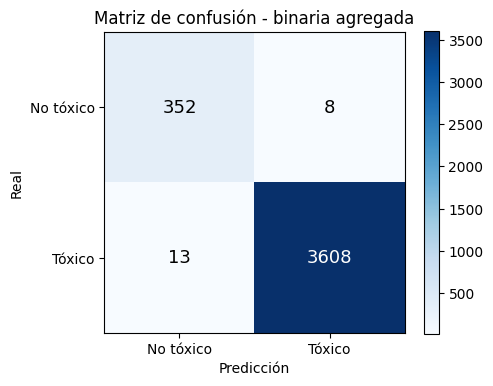

In [18]:
# Matriz de confusión binaria: tóxico vs no tóxico
y_true_bin = (y_true != NON_TOXIC_ID).astype(int)
y_pred_bin = (y_pred != NON_TOXIC_ID).astype(int)

print(f'Support no_tóxico: {(y_true_bin==0).sum()} | tóxico: {(y_true_bin==1).sum()}')
print('=== Reporte binario (tóxico vs no tóxico) ===')
print(classification_report(y_true_bin, y_pred_bin, target_names=['no_tóxico', 'tóxico']))

cm = confusion_matrix(y_true_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No tóxico', 'Tóxico'])
ax.set_yticklabels(['No tóxico', 'Tóxico'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - binaria agregada')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=13)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('confusion_matrix_binary.png', dpi=150)
plt.show()

## 11. Comparativa: modelo base vs. modelo fine-tuned

In [19]:
def predict_finetuned(text: str) -> dict:
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=MAX_LENGTH, padding=True
    ).to(DEVICE)
    ft_model.eval()
    with torch.no_grad():
        outputs = ft_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    pred_id    = int(np.argmax(probs))
    pred_label = id2label[pred_id]
    is_toxic   = pred_label != NON_TOXIC_LABEL

    toxic_probs = {
        id2label[i]: float(probs[i])
        for i in range(len(probs)) if id2label[i] != NON_TOXIC_LABEL
    }
    top3 = sorted(toxic_probs.items(), key=lambda x: -x[1])[:3]

    return {
        'label':          pred_label,
        'is_toxic':       is_toxic,
        'confidence':     round(float(probs[pred_id]), 4),
        'subcategory':    pred_label if is_toxic else None,
        'top3_toxic':     top3,
        'prob_non_toxic': round(float(probs[NON_TOXIC_ID]), 4),
    }

comparison_texts = [
    "Eres un completo idiota que no sirve para nada.",
    "Los inmigrantes son todos criminales.",
    "Los homosexuales no deberían tener derechos.",
    "Qué bonito día hace hoy, vamos al parque.",
    "Te voy a matar si vuelves a hacer eso.",
    "Las mujeres no saben conducir.",
    "Este proyecto está muy bien planteado.",
    "Eres una imbécil que no merece respeto.",
]

print(f"{'Texto':<45} {'BASE':>8}  {'FT LABEL':<28} {'CONF':>6}  {'P(non_toxic)':>12}")
print('-' * 108)

for t in comparison_texts:
    base_r = predict_base(t)
    ft_r   = predict_finetuned(t)
    b_flag = 'X' if base_r['is_toxic'] else 'O'
    f_flag = 'X' if ft_r['is_toxic']   else 'O'
    print(f"{t[:44]:<45} {b_flag}{base_r['max_score']:.2f}  "
          f"{f_flag}{ft_r['label'][:27]:<28} {ft_r['confidence']:.3f}  "
          f"{ft_r['prob_non_toxic']:>12.3f}")

Texto                                             BASE  FT LABEL                       CONF  P(non_toxic)
------------------------------------------------------------------------------------------------------------
Eres un completo idiota que no sirve para na  O0.48  Xinsults_defamation           0.269         0.034
Los inmigrantes son todos criminales.         O0.34  Xxenophobia_discrimination    0.363         0.025
Los homosexuales no deberían tener derechos.  X1.00  Xhomophobia_transphobia       0.871         0.005
Qué bonito día hace hoy, vamos al parque.     O0.00  Xes                           0.359         0.233
Te voy a matar si vuelves a hacer eso.        O0.00  Xes                           0.284         0.105
Las mujeres no saben conducir.                O0.00  Onon_toxic                    0.689         0.689
Este proyecto está muy bien planteado.        O0.00  Onon_toxic                    0.959         0.959
Eres una imbécil que no merece respeto.       O0.02  Xinsults_de

## 12. Clase de moderación para producción

In [20]:
@dataclass
class ModerationResult:
    text:        str
    is_blocked:  bool
    label:       str
    confidence:  float
    subcategory: Optional[str]             = None
    top3_toxic:  List[Tuple[str, float]]   = field(default_factory=list)
    reason:      Optional[str]             = None
    prob_non_toxic: float                  = 0.0


class SpanishContentModerator:
    def __init__(self, model_path: str = SAVE_PATH, threshold: float = 0.5):
        self.threshold      = threshold
        self.id2label       = id2label
        self.label2id       = label2id
        self.non_toxic_label = NON_TOXIC_LABEL
        self.non_toxic_id    = NON_TOXIC_ID
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model     = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.model.to(DEVICE)
        self.model.eval()

    def moderate(self, text: str) -> ModerationResult:
        if not text or not text.strip():
            return ModerationResult(
                text=text, is_blocked=False,
                label=self.non_toxic_label, confidence=1.0,
                prob_non_toxic=1.0
            )

        inputs = self.tokenizer(
            text, return_tensors='pt', truncation=True,
            max_length=MAX_LENGTH, padding=True
        ).to(DEVICE)

        with torch.no_grad():
            outputs = self.model(**inputs)

        probs      = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        pred_id    = int(np.argmax(probs))
        pred_label = self.id2label[pred_id]
        is_toxic   = pred_label != self.non_toxic_label
        confidence = float(probs[pred_id])

        toxic_probs = {
            self.id2label[i]: float(probs[i])
            for i in range(len(probs)) if self.id2label[i] != self.non_toxic_label
        }
        top3 = sorted(toxic_probs.items(), key=lambda x: -x[1])[:3]

        return ModerationResult(
            text=text,
            is_blocked=is_toxic and confidence >= self.threshold,
            label=pred_label,
            confidence=round(confidence, 4),
            subcategory=pred_label if is_toxic else None,
            top3_toxic=top3,
            reason=f'Toxicidad detectada: {pred_label}' if is_toxic else None,
            prob_non_toxic=round(float(probs[self.non_toxic_id]), 4),
        )

    def moderate_batch(self, texts: list) -> list:
        return [self.moderate(t) for t in texts]


# Demo
moderator = SpanishContentModerator(threshold=0.5)

demo_texts = [
    "Hola, ¿en qué te puedo ayudar?",
    "Eres un imbécil de primera.",
    "Los de ese barrio son todos delincuentes.",
    "Los homosexuales no deberían tener derechos.",
    "Me encantó la película, muy recomendable.",
    "Las mujeres no sirven para nada.",
    "Te voy a romper la cara si te veo.",
]

print('=== SpanishContentModerator — demo ===\n')
for text in demo_texts:
    r = moderator.moderate(text)
    status = ' BLOQUEADO' if r.is_blocked else ' PERMITIDO'
    print(f'{status} [{r.confidence:.3f}] {text}')
    if r.subcategory:
        print(f'   Subcategoría: {r.subcategory}')
        top3_str = ', '.join(f'{k}({v:.2f})' for k, v in r.top3_toxic)
        print(f'   Top-3: {top3_str}')
    print()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== SpanishContentModerator — demo ===

 PERMITIDO [0.391] Hola, ¿en qué te puedo ayudar?
   Subcategoría: bulling
   Top-3: bulling(0.39), excessive_swearing(0.28), es(0.04)

 PERMITIDO [0.344] Eres un imbécil de primera.
   Subcategoría: general_insults
   Top-3: general_insults(0.34), explicit_language(0.21), excessive_swearing(0.14)

 PERMITIDO [0.893] Los de ese barrio son todos delincuentes.

 BLOQUEADO [0.871] Los homosexuales no deberían tener derechos.
   Subcategoría: homophobia_transphobia
   Top-3: homophobia_transphobia(0.87), es(0.01), haternet(0.01)

 PERMITIDO [0.959] Me encantó la película, muy recomendable.

 PERMITIDO [0.475] Las mujeres no sirven para nada.

 PERMITIDO [0.308] Te voy a romper la cara si te veo.
   Subcategoría: haternet
   Top-3: haternet(0.31), es(0.22), excessive_swearing(0.12)



## 13. Interfaz Gradio — Chat con filtro integrado

### Implementación completa de `chat_fn` y `clear_chat`

La versión original referenciaba estas funciones sin definirlas, produciendo `NameError` al ejecutar.

In [21]:
# Respuestas del bot según categoría
BLOCKED_RESPONSES = {
    'insults_defamation':    'Tu mensaje contiene insultos. Por favor, reformúlalo con respeto.',
    'hate_speech':           'Se ha detectado discurso de odio. Este tipo de mensaje no está permitido.',
    'xenophobia_discrimination': 'Tu mensaje contiene contenido discriminatorio. Por favor, evita generalizaciones ofensivas.',
    'homophobia_transphobia': 'Se ha detectado contenido homófobo/tránsfobo. Todos merecen respeto.',
    'misogyny':              'Se ha detectado contenido misógino. Por favor, reformula tu mensaje.',
    'threats':               'Tu mensaje contiene amenazas. Este comportamiento no es aceptable.',
    'general_insults':       'Tu mensaje contiene lenguaje ofensivo. Por favor, sé más respetuoso.',
    'explicit_language':     'Tu mensaje contiene lenguaje explícito inapropiado.',
    'excessive_swearing':    'Por favor, evita el lenguaje soez en esta conversación.',
    'racism':                'Se ha detectado contenido racista. Este tipo de mensaje no está permitido.',
}
DEFAULT_BLOCKED_MSG = ' Tu mensaje ha sido bloqueado por contener contenido inapropiado: **{subcategory}**.  \nPor favor, reformúlalo de manera respetuosa.'
DEFAULT_BOT_REPLY   = ' Hola, estoy aquí para ayudarte. ¿En qué puedo asistirte?'


def get_bot_reply(user_text: str, history: list) -> str:
    """Respuesta simple del bot (sustituir por LLM en producción)."""
    greetings = ['hola', 'buenos', 'buenas', 'hey', 'hi', 'saludos']
    if any(g in user_text.lower() for g in greetings):
        return ' ¡Hola! ¿En qué puedo ayudarte hoy?'
    if '?' in user_text:
        return f' Has preguntado: "{user_text[:80]}". Déjame pensar en eso…'
    return f' Recibido: "{user_text[:80]}". ¿Hay algo más en lo que pueda ayudarte?'


def chat_fn(
    user_message: str,
    pdf_file,
    history: list,
) -> tuple:
    """Función principal del chat con moderación integrada."""
    sources_md = ''

    if not user_message or not user_message.strip():
        return history, sources_md

    # Moderación del mensaje del usuario
    result = moderator.moderate(user_message)

    if result.is_blocked:
        # FIX #2: result.subcategory usa NON_TOXIC_LABEL internamente — nunca None aquí
        custom_msg = BLOCKED_RESPONSES.get(result.subcategory)
        bot_reply  = custom_msg if custom_msg else DEFAULT_BLOCKED_MSG.format(
            subcategory=result.subcategory
        )
        top3_str  = '  \n'.join(
            f'- `{k}`: {v:.1%}' for k, v in result.top3_toxic
        )
        sources_md = (
            f'** Análisis de moderación**  \n'
            f'Categoría principal: `{result.subcategory}` ({result.confidence:.1%})  \n'
            f'Top-3 subcategorías tóxicas:  \n{top3_str}'
        )
    else:
        bot_reply = get_bot_reply(user_message, history)
        sources_md = f' Mensaje aprobado (confianza non_toxic: {result.prob_non_toxic:.1%})'

    history = history + [[user_message, bot_reply]]
    return history, sources_md


def clear_chat() -> tuple:
    """Resetea el historial del chat. FIX #4."""
    return [], ''


print(' chat_fn y clear_chat definidas correctamente.')

 chat_fn y clear_chat definidas correctamente.


In [22]:
IN_COLAB = 'google.colab' in sys.modules

with gr.Blocks(
    title='Chat Detector de Contenido Inapropiado',
    theme=gr.themes.Soft(
        primary_hue=gr.themes.colors.green,
        secondary_hue=gr.themes.colors.orange,
        font=[gr.themes.GoogleFont('DM Sans'), 'sans-serif'],
    ),
    css="""
        .source-box {
            background: #f0f7e6;
            border-left: 4px solid #7a9e3b;
            padding: 10px 14px;
            border-radius: 6px;
            font-size: 0.85em;
            color: #4a6741;
        }
        footer { display: none !important; }
        #col-central { max-width: 820px; margin: 0 auto; }
        #row-input { align-items: center; }
    """,
) as demo:

    with gr.Column(elem_id='col-central'):
        gr.Markdown('##  Chat con Filtro de Contenido Inapropiado')
        gr.Markdown(
            f'Modelo: `{SAVE_PATH}` | '
            f'Clases: {NUM_LABELS} | '
            f'Umbral bloqueo: {moderator.threshold:.0%}'
        )

        chatbot = gr.Chatbot(
            label='',
            height=460,
            bubble_full_width=False,
        )

        with gr.Row(elem_id='row-input'):
            pdf_upload = gr.UploadButton(
                '+',
                file_types=['.pdf'],
                file_count='single',
                scale=0,
                min_width=50,
                variant='secondary',
            )
            msg_input = gr.Textbox(
                placeholder='Escribe tu mensaje… (Enter para enviar)',
                label='',
                scale=5,
                lines=2,
                max_lines=5,
                autofocus=True,
            )
            send_btn = gr.Button('Enviar', variant='primary', scale=1)

        sources_box = gr.Markdown(elem_classes=['source-box'])
        clear_btn   = gr.Button('Nueva conversación', variant='stop', size='sm')


    pdf_state = gr.State(value=None)

    pdf_upload.upload(
        fn=lambda f: f,
        inputs=[pdf_upload],
        outputs=[pdf_state],
    )

    send_btn.click(
        fn=chat_fn,
        inputs=[msg_input, pdf_state, chatbot],
        outputs=[chatbot, sources_box],
    ).then(lambda: (None, ''), outputs=[pdf_state, msg_input])

    msg_input.submit(
        fn=chat_fn,
        inputs=[msg_input, pdf_state, chatbot],
        outputs=[chatbot, sources_box],
    ).then(lambda: (None, ''), outputs=[pdf_state, msg_input])

    clear_btn.click(fn=clear_chat, outputs=[chatbot, sources_box])

In [23]:
# share=True crea enlace público en Colab; False abre localhost en entorno local
demo.launch(
    server_name='0.0.0.0',
    share=IN_COLAB,
    show_error=True,
    quiet=False,
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9ab83c896719460444.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
